In [1]:
using Pkg
ENV["JULIA_REVISE_POLL"]="1"
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
using Revise

  Activating project at `~/Github_Projects/JJDFTX.jl`


In [2]:
using PyPlot, PyCall, JJDFTX, LinearAlgebra
interpolate = pyimport("scipy.interpolate").interp1d;
using JJDFTX: fermi, bose

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
total_el_ph = zeros(400)
self_energy_el_ph = zeros(400, 400)
for i in 1:200
    b = np.loadtxt("./self_energy_2/self_energy-muidx1-$i.txt")
    a = np.loadtxt("./self_energy_2/self_energy-muidx1-nums-$i.txt")
    total_el_ph += a
    self_energy_el_ph += b
end
self_energy_el_ph = replace(self_energy_el_ph ./ np.repeat(np.reshape(total_el_ph, (400, 1)), 400, axis=1), NaN=>0);

In [4]:
total_ee_loaded = zeros(400)
self_energy_ee_loaded = zeros(400, 400)
for i in 1:200
    b = np.loadtxt("./self_energy_ee/self_energy-$i.txt")
    a = np.loadtxt("./self_energy_ee/self_energy--nums-$i.txt")
    total_ee_loaded += a
    self_energy_ee_loaded += b
end
self_energy_ee_loaded = replace(self_energy_ee_loaded ./ np.repeat(np.reshape(total_ee_loaded, (400, 1)), 400, axis=1), NaN=>0);

In [6]:
N = 100 #1000
Nprime = 100
plot_len = 100
delta = 0#0.00001
omegas3 = collect(range(-2, 2, length=4*N));
omegas4 = collect(range(-2, 2, length=4*Nprime));

fomegas = fermi.(omegas3, 1);
self_energy = self_energy_el_ph + self_energy_ee_loaded
#self_energy = self_energy_el_ph + self_energy_ee
total = total_ee_loaded
tau_invs3 = zeros(plot_len)
win_len = 1
for (i, omega) in enumerate(range(0.01, 1.16, length=plot_len))
    #println(i); flush(stdout)
    fomegaprimes = fermi.(omegas3 .+ omega, 1);
    omega_idx = round(Int, omega * N)
    tau_inv = 0
    for idx2 in 1:length(omegas4)
        epsilon = omegas4[idx2]
        self_energy_idx = argmin(abs.(epsilon .- omegas3))
        self_energy_epsilon = smooth(self_energy[self_energy_idx, :], win_len=win_len)
        dos_term = total[self_energy_idx] / total[200]
        iszero(dos_term) && continue
        for idx in 1:(4*N-omega_idx)
            omegaprime = omegas3[idx]
            A1 = imag(1/(omega+omegaprime-epsilon+1im*self_energy_epsilon[idx+omega_idx]+1im*delta))
            A2 = imag(1/(omegaprime-epsilon+1im*self_energy_epsilon[idx]+1im*delta))
            tau_inv += dos_term * (omega/pi) * ((1/N)^2) * (-fomegaprimes[idx] + fomegas[idx])*A1*A2
        end
    end
    tau_invs3[i] = tau_inv
end
taus3 = (10^15)*(ħ ./ tau_invs3);

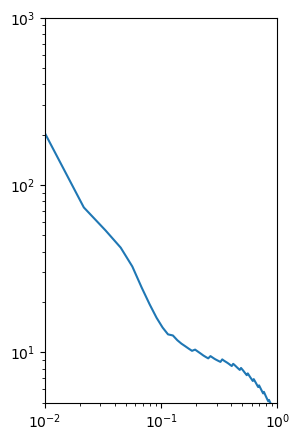

In [7]:
figure(figsize=(3, 5))
loglog(range(0.01, 1.16, length=plot_len), taus3)
ylim(5, 1000)
xlim(0.01, 1);
#savefig("Loss_with_ee.pdf")